# Problem Statement:- Predict whether a passenger survived the Titanic disaster using Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [12]:
df = pd.read_csv("F:/Projects/Titanic_survival_prediction/data/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# # Drop Cabin column
# df.drop("Cabin", axis=1, inplace=True)

In [24]:
df.drop("Cabin", axis=1, inplace=True)

In [15]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [16]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

In [17]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Age"] < lower) |
    (df["Age"] > upper)
]

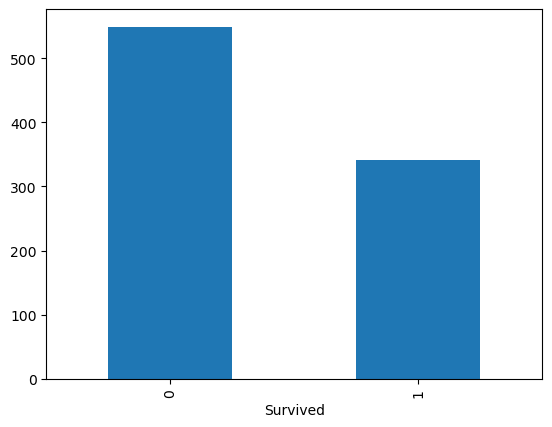

In [18]:
df["Survived"].value_counts().plot(kind="bar")
plt.show()

In [19]:
pd.crosstab(
    df["Sex"],
    df["Survived"]
)

Survived,0,1
Sex,,
0,468,109
1,81,233


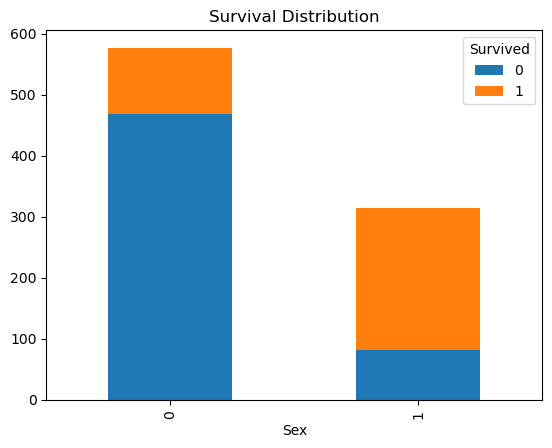

In [57]:
pd.crosstab(
    df["Sex"],
    df["Survived"]
).plot(kind="bar", stacked=True)


plt.title("Survival Distribution")
plt.savefig("F:/Projects/Titanic_survival_prediction/images/survival_by_gender.png")
plt.show()

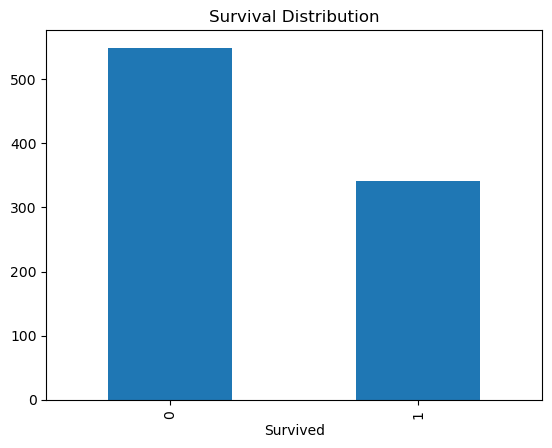

In [55]:


df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.savefig("F:/Projects/Titanic_survival_prediction/images/survival_distribution.png")
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ["Survived","Name","Ticket","PassengerId"],
    axis=1
)

y = df["Survived"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [46]:
predictions = model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print(accuracy)

0.8100558659217877


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [29]:
test_df = pd.read_csv("F:/Projects/Titanic_survival_prediction/data/test.csv")

In [30]:
# Fill missing values
test_df["Age"] = test_df["Age"].fillna(test_df["Age"].median())
test_df["Embarked"] = test_df["Embarked"].fillna(test_df["Embarked"].mode()[0])

# Create FamilySize
test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1

# Drop columns
test_df.drop(["Cabin"], axis=1, inplace=True)

# Encode categorical columns
test_df = pd.get_dummies(
    test_df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [37]:
X_test_final = test_df.reindex(columns=X.columns, fill_value=0)

In [33]:
print(X.isnull().sum())

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
FamilySize    0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [38]:
print(X_test_final.isnull().sum())

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
FamilySize    0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [35]:
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())

In [39]:
predictions = model.predict(X_test_final)

In [41]:
print(predictions[:])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0]


In [42]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

